# LARRY stochastic flow-map clonal comparisons

Load a saved LARRY PCA50 stochastic checkpoint, select a clone observed at both D2 and D4, sample stochastic D2 $\rightarrow$ D4 pushforwards, and compare the generated endpoints with that clone's observed D4 population in PC1--PC2. The model and stochastic sampling still operate in the complete 50-dimensional PCA space.

The notebook uses the checkpoint's saved configuration and EMA parameters. It automatically uses a 50-step Euler--Maruyama rollout for a local-only checkpoint (`local_fraction = 1`); otherwise it uses composed stochastic flow-map sampling.

In [1]:
from pathlib import Path
import json
import sys

import flax
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from ml_collections import ConfigDict

ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "py" / "common" / "larry.py").is_file()
)
if str(ROOT / "py") not in sys.path:
    sys.path.insert(0, str(ROOT / "py"))

from common import larry
from common import maizels_stochastic_eval as stochastic_eval
from common import stochastic_flow_map

print(f"Repository: {ROOT}")
print(f"JAX devices: {jax.devices()}")

Repository: /Users/harryamad/Desktop/drive/2026/flow-maps
JAX devices: [CpuDevice(id=0)]


## PCA50 settings

Set `CHECKPOINT` to a specific `best.msgpack` (or its containing directory), or leave it as `None` to select the newest checkpoint matching `SLURM_ID` and `TRAINING_SEED`. Set `CLONE_ID` after inspecting the table below; `None` chooses the clone with the largest support at both D2 and D4.

In [46]:
# Checkpoint selection. A manual path takes precedence.
CHECKPOINT = None
CHECKPOINT_ROOT = ROOT / "outputs" / "larry_pca50_stochastic"
SLURM_ID = 5
TRAINING_SEED = 0

# Data and clone selection. None uses the path stored in the checkpoint.
DATASET_LOCATION = None
CLONE_ID = 1317
N_PUSHFORWARDS = 32
SAMPLE_SEED = 0
BATCH_SIZE = 2048

# Plotting. The background is subsampled only to keep the figure responsive.
SHOW_BACKGROUND = True
BACKGROUND_MAX_POINTS = 30_000
SAVE_FIGURE = False
FIGURE_PATH = ROOT / "outputs" / "larry_pca50_stochastic_clone_d2_to_d4.png"

In [47]:
def resolve_checkpoint():
    if CHECKPOINT is not None:
        path = Path(CHECKPOINT).expanduser()
        if not path.is_absolute():
            path = ROOT / path
        if path.is_dir():
            path = path / "best.msgpack"
        path = path.resolve()
        if not path.is_file():
            raise FileNotFoundError(f"Checkpoint not found: {path}")
        return path

    pattern = (
        f"sid{int(SLURM_ID)}_*/seed_{int(TRAINING_SEED)}/"
        "checkpoints/*/best.msgpack"
    )
    pattern=("larry_pca50_holdout_d4_bio_prior_minibatch_ot_constrained_ssfm_lr0p001_cw50/best.msgpack")
    candidates = list(Path(CHECKPOINT_ROOT).expanduser().glob(pattern))
    if not candidates:
        raise FileNotFoundError(
            f"No checkpoint matched {Path(CHECKPOINT_ROOT) / pattern}. "
            "Set CHECKPOINT to an explicit best.msgpack path."
        )
    return max(candidates, key=lambda path: path.stat().st_mtime).resolve()


checkpoint_path = resolve_checkpoint()
payload = flax.serialization.msgpack_restore(checkpoint_path.read_bytes())
config_path = checkpoint_path.parent / "config.json"
if config_path.is_file():
    cfg = ConfigDict(json.loads(config_path.read_text()))
elif "config" in payload:
    cfg = ConfigDict(payload["config"])
else:
    raise FileNotFoundError(
        f"Neither {config_path} nor a config in the checkpoint was found."
    )

representation = larry.canonical_representation(
    str(cfg.problem.larry_representation)
)
if representation != larry.PCA50_REPRESENTATION or int(cfg.problem.d) != 50:
    raise ValueError(
        "This section requires a 50D PCA checkpoint; got "
        f"representation={representation!r}, d={int(cfg.problem.d)}."
    )

pc_scale = np.asarray(payload["pc_scale"], dtype=np.float32)
model = stochastic_flow_map.StrongStochasticFlowMapMLP(
    data_dim=int(cfg.problem.d),
    n_coefficients=int(cfg.ssfm.n_coefficients),
    hidden_dim=int(cfg.ssfm.hidden_dim),
    n_hidden=int(cfg.ssfm.n_hidden),
    rescale=float(np.sqrt(np.mean(np.square(pc_scale)))),
    uncertainty_hidden_dim=int(cfg.ssfm.uncertainty_hidden_dim),
)
params = jax.tree_util.tree_map(jnp.asarray, payload["ema_params"])
use_euler_maruyama = stochastic_eval.uses_euler_maruyama_evaluation(cfg)
if use_euler_maruyama:
    sampler_label = (
        f"Euler--Maruyama ({stochastic_eval.euler_maruyama_n_steps(cfg)} steps)"
    )
else:
    sampler_label = (
        f"composed stochastic flow map "
        f"({int(cfg.evaluation.clone_flowmap_n_steps)} steps)"
    )

print(f"Checkpoint: {checkpoint_path}")
print(f"Representation: {representation} ({int(cfg.problem.d)} dimensions)")
print(f"Variant: {cfg.logging.comparison_mode}")
print(f"Training seed: {int(cfg.training.seed)}")
print(f"Best step: {payload.get('best_step', 'unknown')}")
print(f"Sampler: {sampler_label}")

Checkpoint: /Users/harryamad/Desktop/drive/2026/flow-maps/outputs/larry_pca50_stochastic/larry_pca50_holdout_d4_bio_prior_minibatch_ot_constrained_ssfm_lr0p001_cw50/best.msgpack
Representation: pca50 (50 dimensions)
Variant: bio_prior_minibatch_ot_constrained_ssfm
Training seed: 0
Best step: 23600
Sampler: composed stochastic flow map (50 steps)


## Load the clone annotations

Only clones observed at both D2 and D4 are eligible. The table is ordered by the smaller of the two population sizes, then by total size.

In [56]:
dataset_location = (
    Path(DATASET_LOCATION).expanduser()
    if DATASET_LOCATION is not None
    else Path(str(cfg.problem.dataset_location)).expanduser()
)
data = larry.all_timepoint_data(
    dataset_location,
    representation=str(cfg.problem.larry_representation),
)
x = np.asarray(data["x"], dtype=np.float32)
timepoints = np.asarray(data["timepoints"])
clone_ids = np.asarray(data["clone_ids"], dtype=np.int64)
d2_mask = (timepoints == "D2") & (clone_ids >= 0)
d4_mask = (timepoints == "D4") & (clone_ids >= 0)

def clone_counts(mask, name):
    ids, counts = np.unique(clone_ids[mask], return_counts=True)
    return pd.Series(counts, index=ids, name=name, dtype=np.int64)

clone_table = pd.concat(
    [clone_counts(d2_mask, "D2 cells"), clone_counts(d4_mask, "D4 cells")],
    axis=1,
).fillna(0).astype(np.int64)
clone_table = clone_table[
    (clone_table["D2 cells"] > 0) & (clone_table["D4 cells"] > 0)
].copy()
clone_table["minimum count"] = clone_table[["D2 cells", "D4 cells"]].min(axis=1)
clone_table["total count"] = clone_table["D2 cells"] + clone_table["D4 cells"]
clone_table.index.name = "clone_id"
clone_table = clone_table.sort_values(
    ["minimum count", "total count"], ascending=False
)
if clone_table.empty:
    raise RuntimeError("No clone is observed at both D2 and D4.")

display(clone_table.head(30))
selected_clone = int(clone_table.index[0] if CLONE_ID is None else CLONE_ID)
if selected_clone not in clone_table.index:
    raise ValueError(
        f"Clone {selected_clone} is not observed at both D2 and D4. "
        "Choose a clone_id from the table above."
    )

d2_clone_x = x[d2_mask & (clone_ids == selected_clone)]
d4_clone_x = x[d4_mask & (clone_ids == selected_clone)]
print(
    f"Selected clone {selected_clone}: "
    f"{len(d2_clone_x)} D2 cells and {len(d4_clone_x)} D4 cells"
)

,D2 cells,D4 cells,minimum count,total count
clone_id,,,,
4211,6,7,6,13
3530,5,29,5,34
794,5,6,5,11
4087,5,6,5,11
90,5,5,5,10
4141,4,36,4,40
1317,4,10,4,14
3425,4,10,4,14
191,4,8,4,12


Selected clone 1317: 4 D2 cells and 10 D4 cells


## Generate D2 $\rightarrow$ D4 stochastic pushforwards

The requested number of D2 starting cells is sampled uniformly. Sampling is without replacement when the clone contains enough D2 cells and with replacement otherwise; every selected source receives one independent stochastic realization.

In [57]:
if int(N_PUSHFORWARDS) <= 0:
    raise ValueError("N_PUSHFORWARDS must be positive.")
if int(BATCH_SIZE) <= 0:
    raise ValueError("BATCH_SIZE must be positive.")

rng = np.random.default_rng(SAMPLE_SEED)
source_indices = rng.choice(
    len(d2_clone_x),
    size=int(N_PUSHFORWARDS),
    replace=int(N_PUSHFORWARDS) > len(d2_clone_x),
)
source_x = d2_clone_x[source_indices]
start_time = larry.normalized_time("D2", cfg)
end_time = larry.normalized_time("D4", cfg)

def sample_in_batches(points, key):
    slices = [
        slice(start, min(start + int(BATCH_SIZE), len(points)))
        for start in range(0, len(points), int(BATCH_SIZE))
    ]
    keys = jax.random.split(key, len(slices))
    predictions = []
    for batch_slice, batch_key in zip(slices, keys):
        args = (
            model,
            params,
            points[batch_slice],
            start_time,
            end_time,
            batch_key,
        )
        if use_euler_maruyama:
            prediction = stochastic_eval.sample_euler_maruyama_pushforward(
                *args,
                n_coefficients=int(cfg.ssfm.n_coefficients),
                n_steps=stochastic_eval.euler_maruyama_n_steps(cfg),
            )
        else:
            prediction = stochastic_eval.sample_composed_pushforward(
                *args,
                n_coefficients=int(cfg.ssfm.n_coefficients),
                n_steps=int(cfg.evaluation.clone_flowmap_n_steps),
            )
        predictions.append(prediction)
    return np.concatenate(predictions, axis=0)

generated_d4_x = sample_in_batches(
    source_x, jax.random.PRNGKey(int(SAMPLE_SEED))
)
print(
    f"Generated {len(generated_d4_x)} D4 endpoints from "
    f"{len(np.unique(source_indices))} unique D2 cells using {sampler_label}."
)

Generated 32 D4 endpoints from 4 unique D2 cells using composed stochastic flow map (50 steps).


## PCA-space visual comparison

The trajectories are generated in all 50 principal components; this figure displays their projection onto PC1 and PC2.

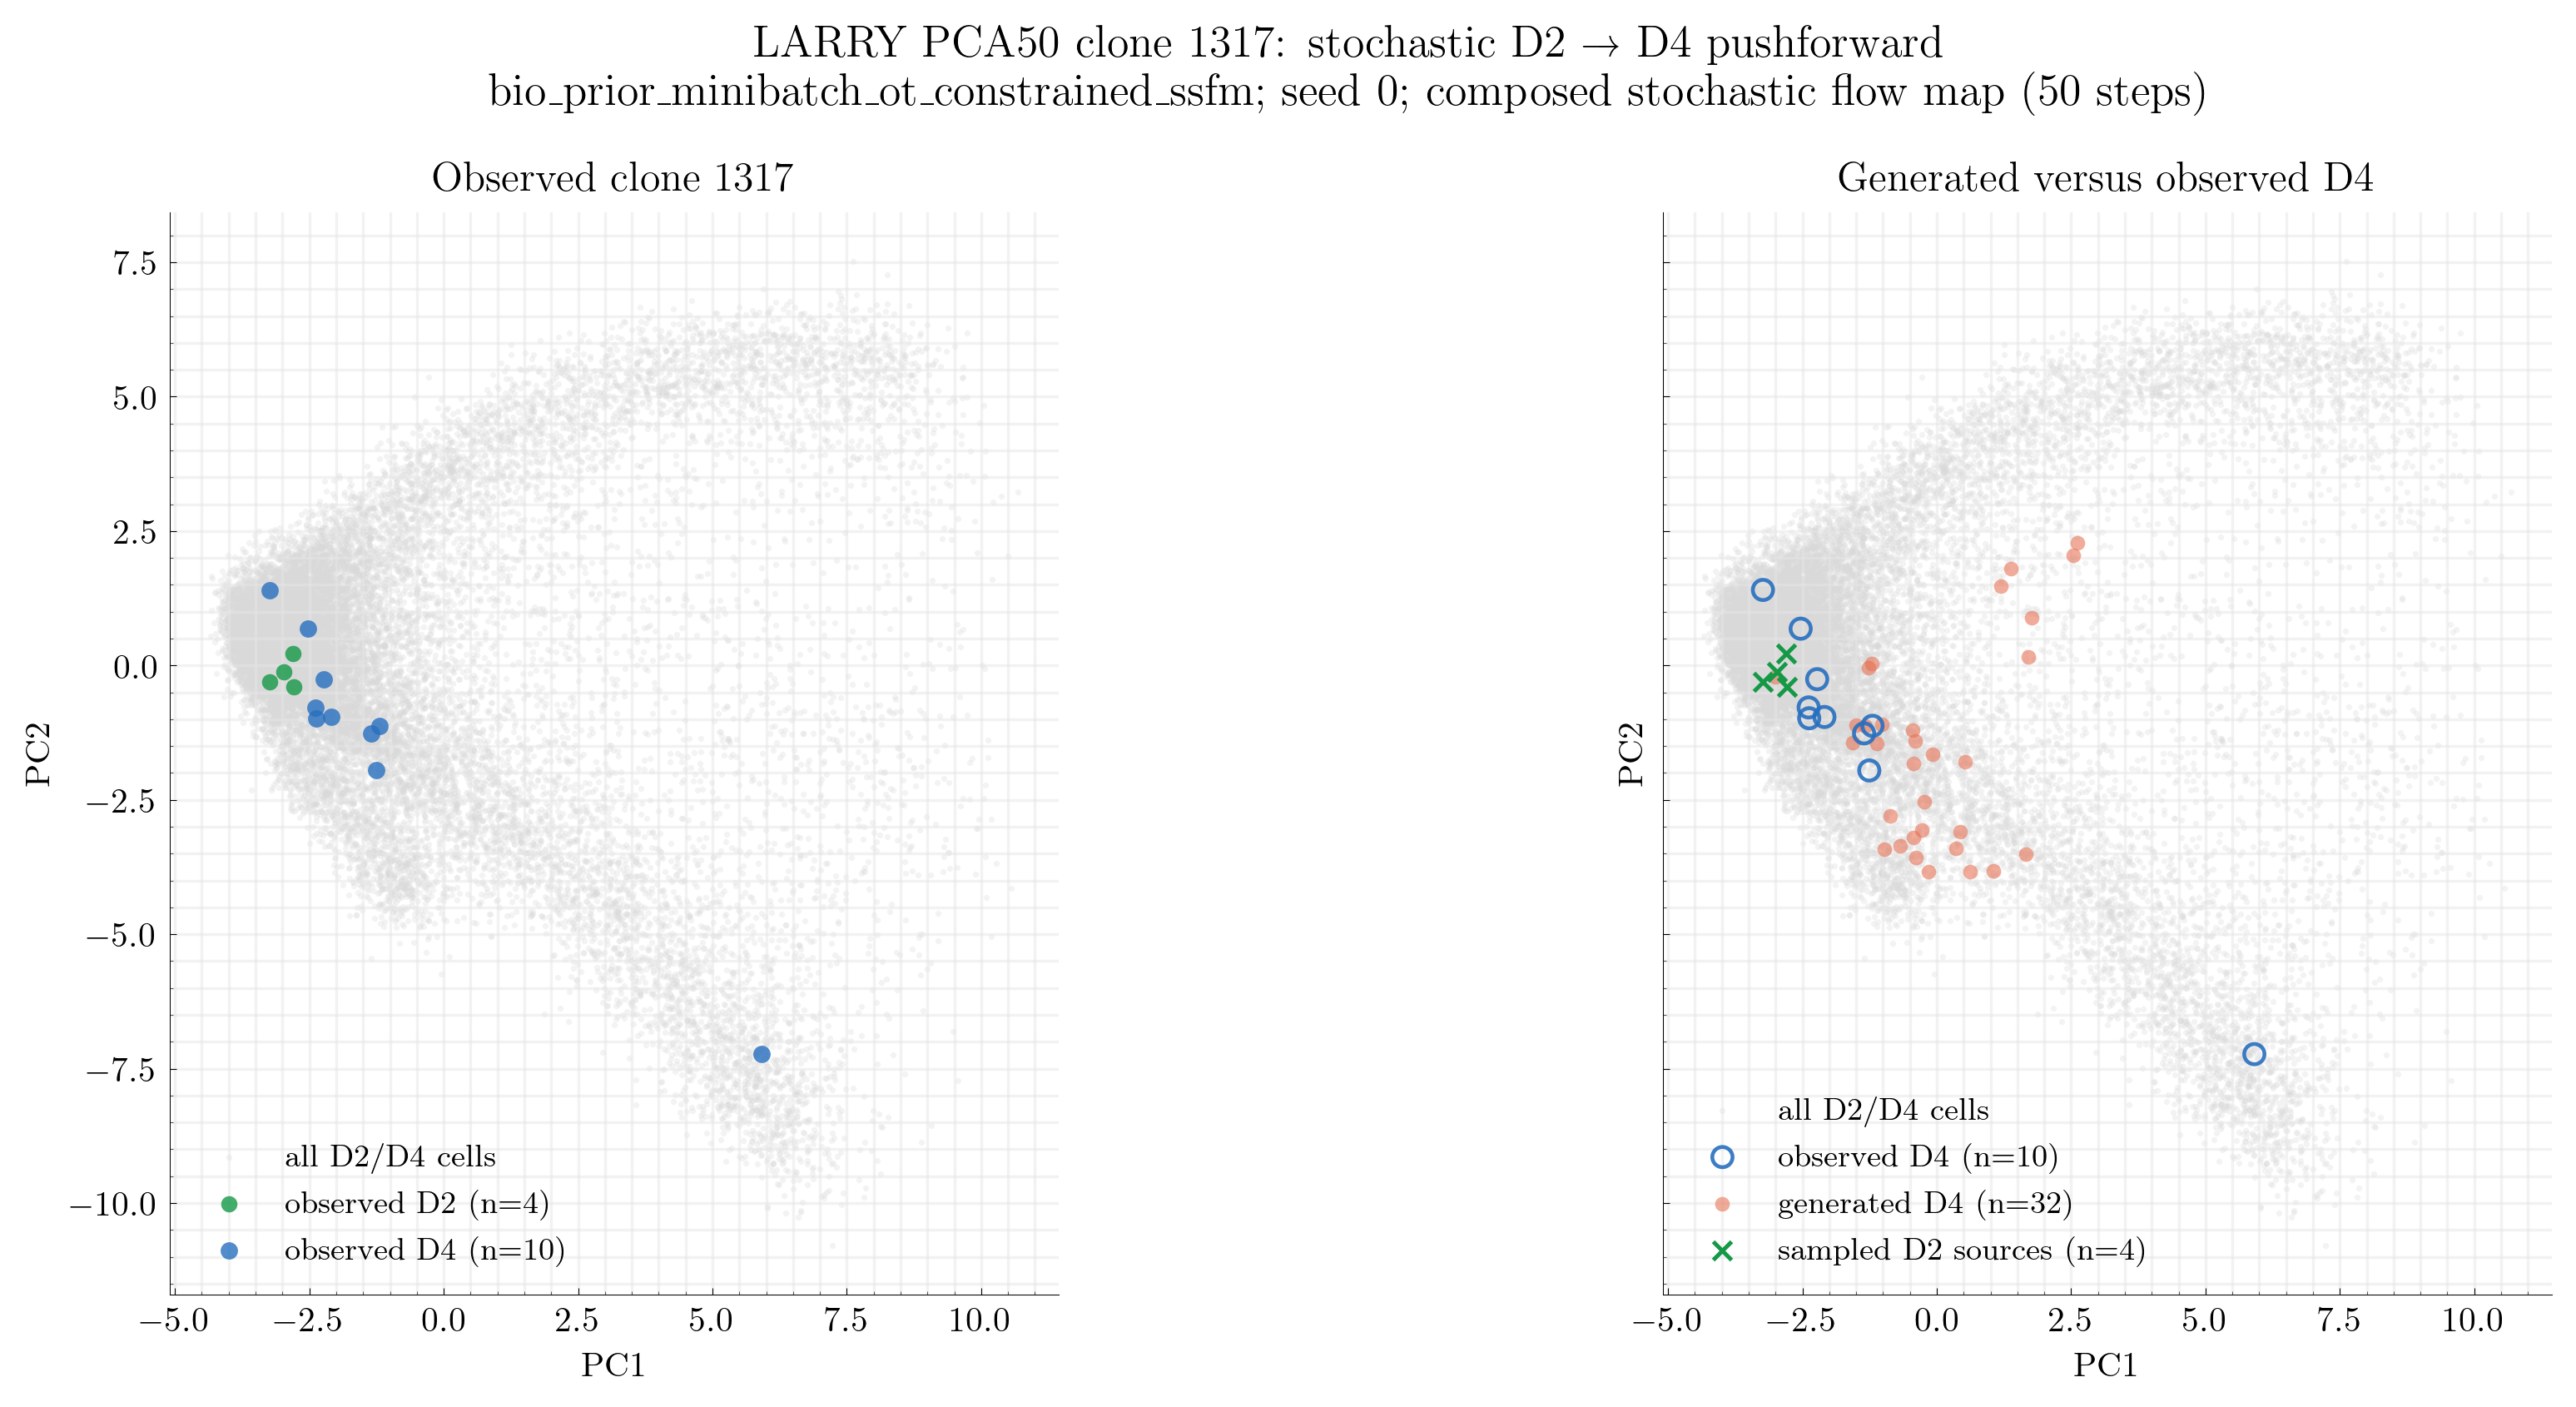

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.7), sharex=True, sharey=True)

if SHOW_BACKGROUND:
    background_indices = np.flatnonzero((timepoints == "D2") | (timepoints == "D4"))
    if len(background_indices) > int(BACKGROUND_MAX_POINTS):
        background_indices = rng.choice(
            background_indices, size=int(BACKGROUND_MAX_POINTS), replace=False
        )
    background = x[background_indices]
    for axis in axes:
        axis.scatter(
            background[:, 0], background[:, 1],
            s=3, c="0.85", alpha=0.3, linewidths=0, label="all D2/D4 cells",
        )

axes[0].scatter(
    d2_clone_x[:, 0], d2_clone_x[:, 1],
    s=22, c="#159947", alpha=0.8, linewidths=0,
    label=f"observed D2 (n={len(d2_clone_x)})", zorder=3,
)
axes[0].scatter(
    d4_clone_x[:, 0], d4_clone_x[:, 1],
    s=25, c="#276FBF", alpha=0.8, linewidths=0,
    label=f"observed D4 (n={len(d4_clone_x)})", zorder=3,
)
axes[0].set_title(f"Observed clone {selected_clone}")

axes[1].scatter(
    d4_clone_x[:, 0], d4_clone_x[:, 1],
    s=34, facecolors="none", edgecolors="#276FBF", alpha=0.9, linewidths=1.1,
    label=f"observed D4 (n={len(d4_clone_x)})", zorder=3,
)
axes[1].scatter(
    generated_d4_x[:, 0], generated_d4_x[:, 1],
    s=18, c="#E76F51", alpha=0.58, linewidths=0,
    label=f"generated D4 (n={len(generated_d4_x)})", zorder=2,
)
unique_source_x = d2_clone_x[np.unique(source_indices)]
axes[1].scatter(
    unique_source_x[:, 0], unique_source_x[:, 1],
    s=28, marker="x", c="#159947", linewidths=1.2,
    label=f"sampled D2 sources (n={len(unique_source_x)})", zorder=4,
)
axes[1].set_title("Generated versus observed D4")

for axis in axes:
    axis.set_xlabel("PC1")
    axis.set_ylabel("PC2")
    axis.set_aspect("equal", adjustable="box")
    axis.legend(frameon=False, fontsize=9, loc="best")
    axis.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"LARRY PCA50 clone {selected_clone}: stochastic D2 → D4 pushforward\n"
    f"{cfg.logging.comparison_mode}; seed {int(cfg.training.seed)}; {sampler_label}",
    fontsize=13,
)
fig.tight_layout()
if SAVE_FIGURE:
    FIGURE_PATH = Path(FIGURE_PATH).expanduser()
    FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURE_PATH, dpi=220, bbox_inches="tight")
    print(f"Saved {FIGURE_PATH.resolve()}")
plt.show()

To compare another clone, set `CLONE_ID` to an ID from the table and rerun from **Load the clone annotations** onward. Change `N_PUSHFORWARDS` for more or fewer stochastic realizations, or set `CHECKPOINT` to compare a different trained model.